# BITRE Road Safety Enforcement - Data Cleaning

Source: Bureau of Infrastructure and Transport Research Economics (BITRE)
Coverage: All Australian states and territories, 2008 to 2024

This notebook cleans three datasets:
- Fines, arrests and charges by offence type
- Positive breath tests and outcomes
- Positive drug tests with substance breakdown

The alcohol/drug tests conducted file (adt) is used only as a denominator for the positivity rate calculation in Section 4. It is not cleaned as a standalone dataset.

Cleaning steps applied across all datasets:
- Lowercase all column names
- Parse dates and add month columns
- Shorten long location labels
- Flag aggregate rows without removing them
- Convert Yes/No string columns to boolean
- Derive useful columns for analysis
- Export clean CSVs to data/clean/

## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 25)
pd.set_option('display.float_format', '{:,.4f}'.format)

DATA_DIR = Path('data/raw')
OUT_DIR  = Path('data/clean')
OUT_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    'fines':  DATA_DIR / 'police_enforcement_2024_fines.xlsx',
    'breath': DATA_DIR / 'police_enforcement_2024_positive_breath_tests.xlsx',
    'drugs':  DATA_DIR / 'police_enforcement_2024_positive_drug_tests.xlsx',
    'adt':    DATA_DIR / 'police_enforcement_2024_alcohol_drug_tests.xlsx',
}

LOCATION_MAP = {
    'Major Cities of Australia': 'Major Cities',
    'Inner Regional Australia':  'Inner Regional',
    'Outer Regional Australia':  'Outer Regional',
    'Remote Australia':          'Remote',
    'Very Remote Australia':     'Very Remote',
    'All regions':               'All regions',
    'Unknown':                   'Unknown',
}

print('Ready. Output folder:', OUT_DIR.resolve())

Ready. Output folder: D:\eh\Swinburne\KNIME\Police enforcement notebook\Data\clean


## 2. Helper Functions

Reusable functions shared across all three dataset sections.

In [2]:
def load_raw(key):
    df = pd.read_excel(FILES[key])
    df.columns = df.columns.str.lower()
    print(f'[{key}] {df.shape[0]:,} rows x {df.shape[1]} cols')
    return df


def add_date_columns(df):
    for col in ('start_date', 'end_date'):
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    if 'start_date' in df.columns:
        df['month']      = df['start_date'].dt.month
        df['month_name'] = df['start_date'].dt.strftime('%b')
    return df


def flag_aggregates(df):
    if 'location' in df.columns:
        df['is_all_locations']    = df['location'].eq('All regions')
        df['is_unknown_location'] = df['location'].eq('Unknown')
    if 'age_group' in df.columns:
        df['is_all_ages']         = df['age_group'].eq('All ages')
        df['is_unknown_age']      = df['age_group'].eq('Unknown')
    return df


def quality_report(df, label):
    print(f'\nQuality report: {label}')
    print(f'  Shape      : {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'  Duplicates : {df.duplicated().sum()}')
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if nulls.empty:
        print('  Nulls      : none')
    else:
        print('  Nulls:')
        for col, n in nulls.items():
            print(f'    {col}: {n:,}')


print('Helper functions ready.')

Helper functions ready.


## 3. Dataset 1 - Fines, Arrests and Charges

File: police_enforcement_2024_fines.xlsx
Shape: 12,179 rows x 11 columns

Covers four offence types: speed, mobile phone, seatbelt, and unlicensed driving.
Broken down by jurisdiction, location, age group, and detection method.
Detailed age and location breakdowns only start from 2023.

In [3]:
fines_raw = load_raw('fines')
fines_raw.head(3)

[fines] 12,179 rows x 11 cols


,year,start_date,end_date,jurisdiction,location,age_group,metric,detection_method,fines,arrests,charges
0,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,non_wearing_seatbelts,Police issued,151,0,2
1,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,speed_fines,Police issued,1888,0,10
2,2024,2024-01-01,2024-01-31,NSW,Major Cities of Australia,40-64,unlicensed_driving,Not applicable,109,0,431


In [4]:
# Check unique values for categorical columns
for col in ['jurisdiction', 'location', 'age_group', 'metric', 'detection_method']:
    print(f'{col}: {sorted(fines_raw[col].unique())}')

jurisdiction: ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
location: ['All regions', 'Inner Regional Australia', 'Major Cities of Australia', 'Outer Regional Australia', 'Remote Australia', 'Unknown', 'Very Remote Australia']
age_group: ['0-16', '17-25', '26-39', '40-64', '65 and over', 'All ages', 'Unknown']
metric: ['mobile_phone_use', 'non_wearing_seatbelts', 'speed_fines', 'unlicensed_driving']
detection_method: ['Average speed camera', 'Fixed camera', 'Fixed or mobile camera', 'Mobile camera', 'Not applicable', 'Other', 'Police issued', 'Red light camera', 'Unknown']


In [5]:
print('Nulls per column:')
print(fines_raw.isnull().sum())
print('\nDuplicate rows:', fines_raw.duplicated().sum())
print('Negative outcome values:', (fines_raw[['fines', 'arrests', 'charges']] < 0).any().any())

Nulls per column:
year                0
start_date          0
end_date            0
jurisdiction        0
location            0
age_group           0
metric              0
detection_method    0
fines               0
arrests             0
charges             0
dtype: int64

Duplicate rows: 0
Negative outcome values: False


In [6]:
fines = fines_raw.copy()

fines = add_date_columns(fines)

fines['location'] = fines['location'].map(LOCATION_MAP)

fines = flag_aggregates(fines)

# Simplify detection method to short labels
fines['detection_method'] = fines['detection_method'].map({
    'Police issued':  'police',
    'Camera':         'camera',
    'Not applicable': np.nan,
})

# Add short display label for each offence type
fines['metric_label'] = fines['metric'].map({
    'speed_fines':           'Speed',
    'mobile_phone_use':      'Mobile Phone',
    'non_wearing_seatbelts': 'Seatbelt',
    'unlicensed_driving':    'Unlicensed Driving',
})

fines['pre_2023'] = fines['year'] < 2023

fines['total_actions'] = fines['fines'] + fines['arrests'] + fines['charges']

quality_report(fines, 'fines')


Quality report: fines
  Shape      : 12,179 rows x 20 cols
  Duplicates : 644
  Nulls:
    detection_method: 6,415


In [7]:
(
    fines[fines['is_all_locations'] & fines['is_all_ages']]
    .groupby('metric_label')[['fines', 'arrests', 'charges']]
    .sum()
    .sort_values('fines', ascending=False)
)

,fines,arrests,charges
metric_label,,,
Speed,52094900,0,0
Mobile Phone,2450159,0,0
Seatbelt,290139,0,0


In [8]:
fines.to_csv(OUT_DIR / 'fines_clean.csv', index=False)
print('Saved: data/clean/fines_clean.csv')
print(f'Shape: {fines.shape[0]:,} rows x {fines.shape[1]} cols')
print('Columns:', list(fines.columns))

Saved: data/clean/fines_clean.csv
Shape: 12,179 rows x 20 cols
Columns: ['year', 'start_date', 'end_date', 'jurisdiction', 'location', 'age_group', 'metric', 'detection_method', 'fines', 'arrests', 'charges', 'month', 'month_name', 'is_all_locations', 'is_unknown_location', 'is_all_ages', 'is_unknown_age', 'metric_label', 'pre_2023', 'total_actions']


## 4. Dataset 2 - Positive Breath Tests

File: police_enforcement_2024_positive_breath_tests.xlsx
Shape: 1,326 rows x 12 columns

Records the number of positive breath tests and enforcement outcomes (fines, arrests, charges)
broken down by jurisdiction, location, and age group.

We also merge this with the adt file to compute the drink-drive positivity rate,
which is the share of all tests that returned a positive result.

In [9]:
# Load and preview
breath_raw = load_raw('breath')
breath_raw.head(3)

[breath] 1,326 rows x 12 cols


,year,start_date,end_date,jurisdiction,location,age_group,metric,detection_method,count,fines,arrests,charges
0,2008,2008-01-01,2008-12-31,ACT,All regions,All ages,positive_breath_tests,Not applicable,1887,0,0,0
1,2008,2008-01-01,2008-12-31,NSW,All regions,All ages,positive_breath_tests,Not applicable,27368,0,0,0
2,2008,2008-01-01,2008-12-31,NT,All regions,All ages,positive_breath_tests,Not applicable,9460,0,0,0


In [10]:
for col in ['jurisdiction', 'location', 'age_group', 'metric', 'detection_method']:
    print(f'{col}: {sorted(breath_raw[col].unique())}')

jurisdiction: ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
location: ['All regions', 'Inner Regional Australia', 'Major Cities of Australia', 'Outer Regional Australia', 'Remote Australia', 'Unknown', 'Very Remote Australia']
age_group: ['0-16', '17-25', '26-39', '40-64', '65 and over', 'All ages', 'Unknown']
metric: ['positive_breath_tests']
detection_method: ['Not applicable']


In [11]:
print('Nulls per column:')
print(breath_raw.isnull().sum())
print('\nDuplicate rows:', breath_raw.duplicated().sum())
print('Zero-count rows:', (breath_raw['count'] == 0).sum())

Nulls per column:
year                0
start_date          0
end_date            0
jurisdiction        0
location            0
age_group           0
metric              0
detection_method    0
count               0
fines               0
arrests             0
charges             0
dtype: int64

Duplicate rows: 0
Zero-count rows: 120


In [12]:
breath = breath_raw.copy()

breath = add_date_columns(breath)

breath['location'] = breath['location'].map(LOCATION_MAP)

breath = flag_aggregates(breath)

breath = breath.rename(columns={'count': 'positive_breath_tests'})

assert breath['metric'].nunique() == 1
breath = breath.drop(columns=['metric'])

assert breath['detection_method'].nunique() == 1
breath = breath.drop(columns=['detection_method'])

# Total outcomes per row and rate of outcomes per positive test
# outcome_rate shows how often a positive test leads to a fine, arrest, or charge
breath['total_outcomes'] = breath['fines'] + breath['arrests'] + breath['charges']
breath['outcome_rate'] = np.where(
    breath['positive_breath_tests'] > 0,
    (breath['total_outcomes'] / breath['positive_breath_tests']).round(4),
    np.nan
)


breath['pre_2023'] = breath['year'] < 2023

quality_report(breath, 'breath')


Quality report: breath
  Shape      : 1,326 rows x 19 cols
  Duplicates : 0
  Nulls:
    outcome_rate: 120


In [13]:
# Formula: positive_breath_tests / breath_tests_conducted * 100

adt_raw = load_raw('adt')
adt_breath = (
    adt_raw[adt_raw['metric'] == 'breath_tests_conducted']
    .groupby(['year', 'jurisdiction'], as_index=False)['count']
    .sum()
    .rename(columns={'count': 'breath_tests_total'})
)

# Aggregate positive tests to one row per year and jurisdiction
breath_agg = (
    breath[breath['is_all_locations'] & breath['is_all_ages']]
    .groupby(['year', 'jurisdiction'], as_index=False)['positive_breath_tests']
    .sum()
)

# Merge and calculate the rate
positivity = breath_agg.merge(adt_breath, on=['year', 'jurisdiction'], how='left')
positivity['positivity_rate_pct'] = (
    positivity['positive_breath_tests'] / positivity['breath_tests_total'] * 100
).round(4)

print('Top 10 highest positivity rates:')
positivity.sort_values('positivity_rate_pct', ascending=False).head(10)

[adt] 530 rows x 7 cols
Top 10 highest positivity rates:


,year,jurisdiction,positive_breath_tests,breath_tests_total,positivity_rate_pct
2,2008,NT,9460,111662,8.4720
42,2013,NT,12395,156719,7.9091
58,2015,NT,14192,181843,7.8045
112,2022,NT,5120,65819,7.7789
50,2014,NT,13562,175914,7.7094
98,2020,NT,7362,103102,7.1405
10,2009,NT,10990,159374,6.8957
105,2021,NT,5492,81987,6.6986
18,2010,NT,10842,181626,5.9694
34,2012,NT,9332,167667,5.5658


In [14]:
breath.to_csv(OUT_DIR / 'breath_clean.csv', index=False)
positivity.to_csv(OUT_DIR / 'breath_positivity_rate.csv', index=False)

print('Saved: data/clean/breath_clean.csv')
print(f'Shape: {breath.shape[0]:,} rows x {breath.shape[1]} cols')
print('Columns:', list(breath.columns))
print('\nSaved: data/clean/breath_positivity_rate.csv')
print(f'Shape: {positivity.shape[0]:,} rows x {positivity.shape[1]} cols')

Saved: data/clean/breath_clean.csv
Shape: 1,326 rows x 19 cols
Columns: ['year', 'start_date', 'end_date', 'jurisdiction', 'location', 'age_group', 'positive_breath_tests', 'fines', 'arrests', 'charges', 'month', 'month_name', 'is_all_locations', 'is_unknown_location', 'is_all_ages', 'is_unknown_age', 'total_outcomes', 'outcome_rate', 'pre_2023']

Saved: data/clean/breath_positivity_rate.csv
Shape: 117 rows x 5 cols


## 5. Dataset 3 - Positive Drug Tests

File: police_enforcement_2024_positive_drug_tests.xlsx
Shape: 7,982 rows x 21 columns

Records positive drug tests with per-substance flag columns: amphetamine, cannabis, cocaine,
ecstasy, methylamphetamine, other, unknown, and no_drugs_detected.
These are stored as Yes/No strings and will be converted to booleans.

A single test can flag more than one substance at the same time.

In [15]:
drugs_raw = load_raw('drugs')
drugs_raw.head(3)

[drugs] 7,982 rows x 21 cols


,year,start_date,end_date,jurisdiction,location,age_group,metric,best_detection_method,detection_method,amphetamine,cannabis,cocaine,ecstasy,methylamphetamine,other,unknown,no_drugs_detected,count,fines,arrests,charges
0,2008,2008-01-01,2008-12-31,NSW,All regions,All ages,positive_drug_tests,Yes,Indicator (Stage 1),No,No,No,No,No,No,Yes,No,542,0,0,0
1,2008,2008-01-01,2008-12-31,QLD,All regions,All ages,positive_drug_tests,Yes,Indicator (Stage 1),No,No,No,No,No,No,Yes,No,216,0,0,0
2,2008,2008-01-01,2008-12-31,SA,All regions,All ages,positive_drug_tests,Yes,Indicator (Stage 1),No,No,No,No,No,No,Yes,No,600,0,0,0


In [16]:
for col in ['jurisdiction', 'location', 'age_group', 'detection_method', 'best_detection_method']:
    print(f'{col}: {sorted(drugs_raw[col].unique())}')

DRUG_FLAG_COLS = [
    'amphetamine', 'cannabis', 'cocaine', 'ecstasy',
    'methylamphetamine', 'other', 'unknown', 'no_drugs_detected'
]

print('\nDrug flag unique values:')
for col in DRUG_FLAG_COLS:
    print(f'  {col}: {drugs_raw[col].unique().tolist()}')

jurisdiction: ['ACT', 'NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']
location: ['All regions', 'Inner Regional Australia', 'Major Cities of Australia', 'Outer Regional Australia', 'Remote Australia', 'Unknown', 'Very Remote Australia']
age_group: ['0-16', '17-25', '26-39', '40-64', '65 and over', 'All ages', 'Unknown']
detection_method: ['Indicator (Stage 1)', 'Laboratory or Toxicology (Stage 3)', 'Not applicable', 'Secondary Confirmatory (Stage 2)']
best_detection_method: ['No', 'Yes']

Drug flag unique values:
  amphetamine: ['No', 'Yes', 'Not applicable']
  cannabis: ['No', 'Yes', 'Not applicable']
  cocaine: ['No', 'Yes', 'Not applicable']
  ecstasy: ['No', 'Not applicable', 'Yes']
  methylamphetamine: ['No', 'Not applicable', 'Yes']
  other: ['No', 'Yes', 'Not applicable']
  unknown: ['Yes', 'No', 'Not applicable']
  no_drugs_detected: ['No', 'Not applicable', 'Yes']


In [17]:
print('Nulls per column:')
print(drugs_raw.isnull().sum())
print('\nDuplicate rows:', drugs_raw.duplicated().sum())
print('Zero-count rows:', (drugs_raw['count'] == 0).sum())

Nulls per column:
year                     0
start_date               0
end_date                 0
jurisdiction             0
location                 0
age_group                0
metric                   0
best_detection_method    0
detection_method         0
amphetamine              0
cannabis                 0
cocaine                  0
ecstasy                  0
methylamphetamine        0
other                    0
unknown                  0
no_drugs_detected        0
count                    0
fines                    0
arrests                  0
charges                  0
dtype: int64

Duplicate rows: 0
Zero-count rows: 490


In [18]:
drugs = drugs_raw.copy()

drugs = add_date_columns(drugs)

drugs['location'] = drugs['location'].map(LOCATION_MAP)

drugs = flag_aggregates(drugs)

drugs = drugs.rename(columns={'count': 'positive_drug_tests'})

assert drugs['metric'].nunique() == 1
drugs = drugs.drop(columns=['metric'])

YES_NO = {'Yes': True, 'No': False}
for col in DRUG_FLAG_COLS:
    drugs[col] = drugs[col].map(YES_NO)

drugs['best_detection_method'] = drugs['best_detection_method'].map(YES_NO)

SUBSTANCE_COLS   = ['amphetamine', 'cannabis', 'cocaine', 'ecstasy', 'methylamphetamine', 'other', 'unknown']
SUBSTANCE_LABELS = ['Amphetamine', 'Cannabis', 'Cocaine', 'Ecstasy', 'Methylamphetamine', 'Other', 'Unknown']

def make_combo(row):
    if row.get('no_drugs_detected', False):
        return 'None detected'
    flagged = [lbl for col, lbl in zip(SUBSTANCE_COLS, SUBSTANCE_LABELS) if row.get(col, False)]
    return ' + '.join(flagged) if flagged else 'Unknown'

drugs['substance_combo'] = drugs.apply(make_combo, axis=1)

# Mark rows before 2023
drugs['pre_2023'] = drugs['year'] < 2023

drugs['total_outcomes'] = drugs['fines'] + drugs['arrests'] + drugs['charges']

quality_report(drugs, 'drugs')


Quality report: drugs
  Shape      : 7,982 rows x 29 cols
  Duplicates : 0
  Nulls:
    amphetamine: 1,027
    cannabis: 285
    cocaine: 2,341
    ecstasy: 3,315
    methylamphetamine: 7,170
    other: 7,657
    unknown: 6,276
    no_drugs_detected: 6,780


In [19]:
drugs[[
    'year', 'jurisdiction', 'age_group', 'location',
    'detection_method', 'positive_drug_tests',
    'amphetamine', 'cannabis', 'methylamphetamine',
    'substance_combo', 'total_outcomes'
]].head(6)

,year,jurisdiction,age_group,location,detection_method,positive_drug_tests,amphetamine,cannabis,methylamphetamine,substance_combo,total_outcomes
0,2008,NSW,All ages,All regions,Indicator (Stage 1),542,False,False,False,Unknown,0
1,2008,QLD,All ages,All regions,Indicator (Stage 1),216,False,False,False,Unknown,0
2,2008,SA,All ages,All regions,Indicator (Stage 1),600,False,False,False,Unknown,0
3,2008,TAS,All ages,All regions,Indicator (Stage 1),211,False,False,False,Unknown,0
4,2008,VIC,All ages,All regions,Indicator (Stage 1),438,False,False,False,Unknown,0
5,2008,WA,All ages,All regions,Indicator (Stage 1),406,False,False,False,Unknown,0


In [20]:
# Build a year-level substance summary table
# Summing boolean columns counts how many tests flagged each substance
drug_summary = (
    drugs[drugs['is_all_locations'] & drugs['is_all_ages']]
    .groupby('year')[SUBSTANCE_COLS + ['positive_drug_tests']]
    .sum()
    .reset_index()
)

for col in SUBSTANCE_COLS:
    drug_summary[f'{col}_pct'] = (
        drug_summary[col] / drug_summary['positive_drug_tests'] * 100
    ).round(2)

print('Substance detection counts by year:')
drug_summary[['year'] + SUBSTANCE_COLS + ['positive_drug_tests']]

Substance detection counts by year:


,year,amphetamine,cannabis,cocaine,ecstasy,methylamphetamine,other,unknown,positive_drug_tests
0,2008,0,0,0,0,0,0,6,2413
1,2009,0,0,0,0,0,0,6,2910
2,2010,0,0,0,0,0,0,5,4033
3,2011,0,0,0,0,0,0,6,5604
4,2012,0,0,0,0,0,0,7,8242
5,2013,0,0,0,0,0,0,8,9853
6,2014,0,0,0,0,0,0,8,16289
7,2015,0,0,0,0,0,0,8,35143
8,2016,0,0,0,0,0,0,8,38703
9,2017,0,0,0,0,0,0,8,39855


In [21]:
drugs.to_csv(OUT_DIR / 'drugs_clean.csv', index=False)
drug_summary.to_csv(OUT_DIR / 'drugs_substance_by_year.csv', index=False)

print('Saved: data/clean/drugs_clean.csv')
print(f'Shape: {drugs.shape[0]:,} rows x {drugs.shape[1]} cols')
print('Columns:', list(drugs.columns))
print('\nSaved: data/clean/drugs_substance_by_year.csv')
print(f'Shape: {drug_summary.shape[0]:,} rows x {drug_summary.shape[1]} cols')

Saved: data/clean/drugs_clean.csv
Shape: 7,982 rows x 29 cols
Columns: ['year', 'start_date', 'end_date', 'jurisdiction', 'location', 'age_group', 'best_detection_method', 'detection_method', 'amphetamine', 'cannabis', 'cocaine', 'ecstasy', 'methylamphetamine', 'other', 'unknown', 'no_drugs_detected', 'positive_drug_tests', 'fines', 'arrests', 'charges', 'month', 'month_name', 'is_all_locations', 'is_unknown_location', 'is_all_ages', 'is_unknown_age', 'substance_combo', 'pre_2023', 'total_outcomes']

Saved: data/clean/drugs_substance_by_year.csv
Shape: 15 rows x 16 cols


## 6. Final Summary

In [22]:
cleaned_datasets = {
    'fines_clean.csv':             fines,
    'breath_clean.csv':            breath,
    'breath_positivity_rate.csv':  positivity,
    'drugs_clean.csv':             drugs,
    'drugs_substance_by_year.csv': drug_summary,
}

print(f'{"File":<35} {"Rows":>8} {"Cols":>6} {"Nulls":>8} {"Dupes":>8}')
print('-' * 68)
for name, df in cleaned_datasets.items():
    nulls = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    print(f'{name:<35} {len(df):>8,} {df.shape[1]:>6} {nulls:>8,} {dupes:>8}')

File                                    Rows   Cols    Nulls    Dupes
--------------------------------------------------------------------
fines_clean.csv                       12,179     20    6,415      644
breath_clean.csv                       1,326     19      120        0
breath_positivity_rate.csv               117      5        0        0
drugs_clean.csv                        7,982     29   34,851        0
drugs_substance_by_year.csv               15     16        0        0


In [23]:
notes = """
Some nulls are expected and intentional:

fines_clean.csv
  detection_method is NaN where the original value was 'Not applicable'
  This applies to unlicensed driving which cannot be detected by camera

breath_clean.csv
  outcome_rate is NaN where positive_breath_tests equals zero
  This prevents division by zero

breath_positivity_rate.csv
  breath_tests_total and positivity_rate_pct are NaN for jurisdictions
  and years that have no matching record in the adt file

All other columns across all files have zero nulls.
"""
print(notes)


Some nulls are expected and intentional:

fines_clean.csv
  detection_method is NaN where the original value was 'Not applicable'
  This applies to unlicensed driving which cannot be detected by camera

breath_clean.csv
  outcome_rate is NaN where positive_breath_tests equals zero
  This prevents division by zero

breath_positivity_rate.csv
  breath_tests_total and positivity_rate_pct are NaN for jurisdictions
  and years that have no matching record in the adt file

All other columns across all files have zero nulls.



## 7. Exploratory Data Analysis — Visual Insights

Six charts answering specific questions about the data.
Run this section after completing Sections 3, 4, and 5 so all dataframes are in memory.

Questions:
- Q1: Which offence type generates the most fines, and how has that changed over time?
- Q2: Is mobile phone enforcement growing? What drove the jump?
- Q3: Which age group receives the most fines? (2023-2024 granular data)
- Q4: How has the drug detection substance mix shifted from 2008 to 2024?
- Q5: Does drink-drive detection vary by location type?
- Q6: Which states have improved most on drink-driving rates over time?

### Setup — matplotlib style

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

# If EDA is run standalone, load cleaned CSVs into memory
clean_dir_candidates = [Path('data/clean'), Path('Data/clean')]
clean_dir = next((p for p in clean_dir_candidates if p.exists()), clean_dir_candidates[0])

if 'fines' not in globals():
    fines = pd.read_csv(clean_dir / 'fines_clean.csv')
if 'breath' not in globals():
    breath = pd.read_csv(clean_dir / 'breath_clean.csv')
if 'drugs' not in globals():
    drugs = pd.read_csv(clean_dir / 'drugs_clean.csv')
if 'positivity' not in globals():
    positivity = pd.read_csv(clean_dir / 'breath_positivity_rate.csv')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8FAFC',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#E2E8F0',
    'grid.linewidth': 0.8,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
})

PALETTE = ['#0D2B55', '#0891B2', '#3B82F6', '#94A3B8', '#06B6D4']
print('Matplotlib ready. Loaded clean data from:', clean_dir.resolve())
print('Shapes -> fines:', fines.shape, '| breath:', breath.shape, '| drugs:', drugs.shape, '| positivity:', positivity.shape)

Matplotlib ready. Loaded clean data from: D:\eh\Swinburne\KNIME\Police enforcement notebook\Data\clean
Shapes -> fines: (12179, 20) | breath: (1326, 19) | drugs: (7982, 29) | positivity: (117, 5)


### Q1: Which offence type generates the most fines over time?

Uses All regions + All ages aggregate rows to get one national number per year per offence.
This avoids double counting granular rows.

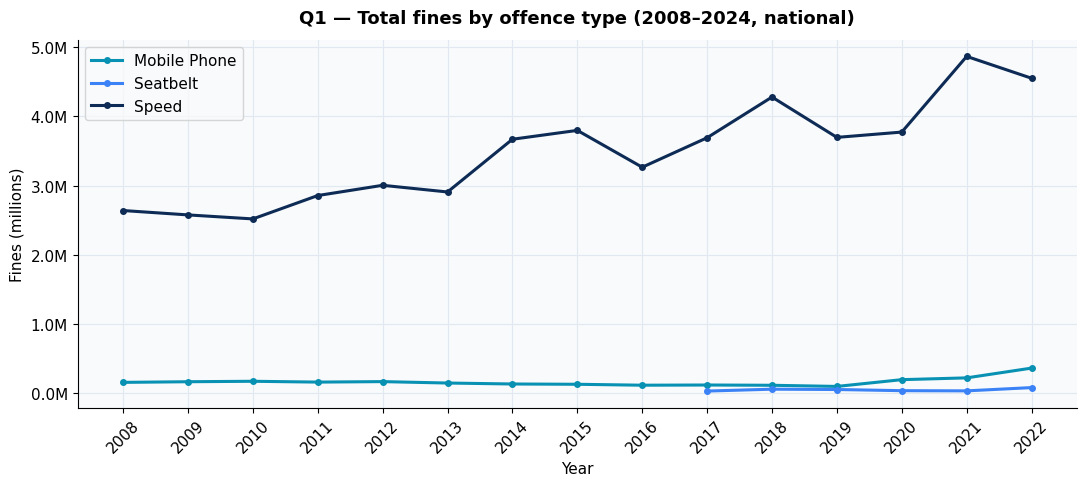

Key finding: Speed fines dominate throughout. Mobile phone fines grew sharply from 2012 as camera detection expanded.


In [25]:
fines_trend = (
    fines[fines['is_all_locations'] & fines['is_all_ages']]
    .groupby(['year', 'metric_label'])['fines']
    .sum()
    .unstack('metric_label')
)

fig, ax = plt.subplots(figsize=(11, 5))

colors = {'Speed': PALETTE[0], 'Mobile Phone': PALETTE[1], 'Seatbelt': PALETTE[2], 'Unlicensed Driving': PALETTE[3]}
for col in fines_trend.columns:
    ax.plot(fines_trend.index, fines_trend[col] / 1e6, marker='o', markersize=4,
            linewidth=2.2, label=col, color=colors.get(col, 'grey'))

ax.set_title('Q1 — Total fines by offence type (2008–2024, national)')
ax.set_xlabel('Year')
ax.set_ylabel('Fines (millions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.legend(loc='upper left', framealpha=0.8)
ax.set_xticks(fines_trend.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_q1_fines_by_offence.png', dpi=150)
plt.show()

print('Key finding: Speed fines dominate throughout. Mobile phone fines grew sharply from 2012 as camera detection expanded.')

### Q2: Is mobile phone fine growth driven by camera detection?

Splits mobile phone fines by detection method to show what caused the post-2012 surge.
Rows where detection_method is NaN (Not applicable) are excluded.

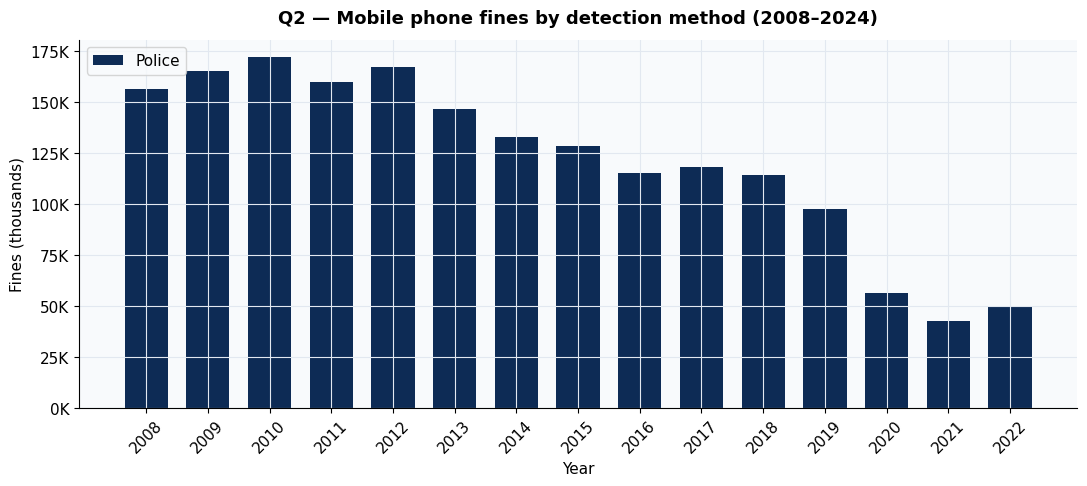

Key finding: Camera detection drives almost all growth. Police-issued phone fines are relatively flat.


In [26]:
phone = (
    fines[
        (fines['metric'] == 'mobile_phone_use') &
        fines['is_all_locations'] &
        fines['is_all_ages'] &
        fines['detection_method'].notna()
    ]
    .groupby(['year', 'detection_method'])['fines']
    .sum()
    .unstack('detection_method')
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 5))

bottom = np.zeros(len(phone))
det_colors = {'police': PALETTE[0], 'camera': PALETTE[1]}
for method in phone.columns:
    ax.bar(phone.index, phone[method] / 1e3, bottom=bottom,
           label=method.title(), color=det_colors.get(method, 'grey'), width=0.7)
    bottom += phone[method].values / 1e3

ax.set_title('Q2 — Mobile phone fines by detection method (2008–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Fines (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.legend(loc='upper left', framealpha=0.8)
ax.set_xticks(phone.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_q2_phone_by_detection.png', dpi=150)
plt.show()

print('Key finding: Camera detection drives almost all growth. Police-issued phone fines are relatively flat.')

### Q3: Which age group receives the most fines? (2023–2024 only)

Age breakdowns only exist from 2023. In 2023–2024 the data has no All regions rows —
every row has a specific location. So we sum across all non-Unknown, non-aggregate
locations to get a national total per age group.

Fix applied: do not filter on is_all_locations — instead exclude Unknown location
and All ages / Unknown age rows, then group by age and sum across all locations.

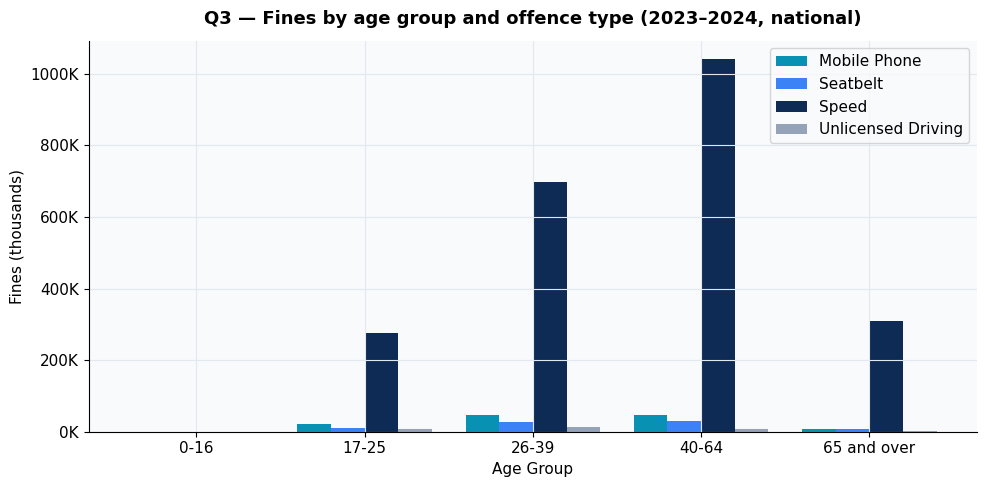

Key finding: The 40-64 group receives the most fines. The 17-25 group has a disproportionately high share of mobile phone fines relative to population size.


In [27]:
age_fines = (
    fines[
        (fines['year'] >= 2023) &
        ~fines['is_all_locations'] &
        ~fines['is_unknown_location'] &
        ~fines['is_all_ages'] &
        ~fines['is_unknown_age']
    ]
    .groupby(['age_group', 'metric_label'])['fines']
    .sum()
    .unstack('metric_label')
    .fillna(0)
)

age_order = ['0-16', '17-25', '26-39', '40-64', '65 and over']
age_fines = age_fines.reindex(age_order)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(age_fines))
width = 0.2
offence_colors = {'Speed': PALETTE[0], 'Mobile Phone': PALETTE[1], 'Seatbelt': PALETTE[2], 'Unlicensed Driving': PALETTE[3]}
for i, col in enumerate(age_fines.columns):
    ax.bar(x + i * width, age_fines[col] / 1e3, width=width,
           label=col, color=offence_colors.get(col, 'grey'))

ax.set_title('Q3 — Fines by age group and offence type (2023–2024, national)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Fines (thousands)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(age_order)
ax.legend(loc='upper right', framealpha=0.8)
plt.tight_layout()
plt.savefig('eda_q3_fines_by_age.png', dpi=150)
plt.show()

print('Key finding: The 40-64 group receives the most fines. The 17-25 group has a disproportionately high share of mobile phone fines relative to population size.')

### Q4: How has the drug detection substance mix shifted from 2008 to 2024?

Fix applied: boolean columns read from CSV come back as object dtype with string values
'True' / 'False'. We cast explicitly to int (1/0) before summing.
Using aggregate rows (All regions + All ages) prevents double counting.

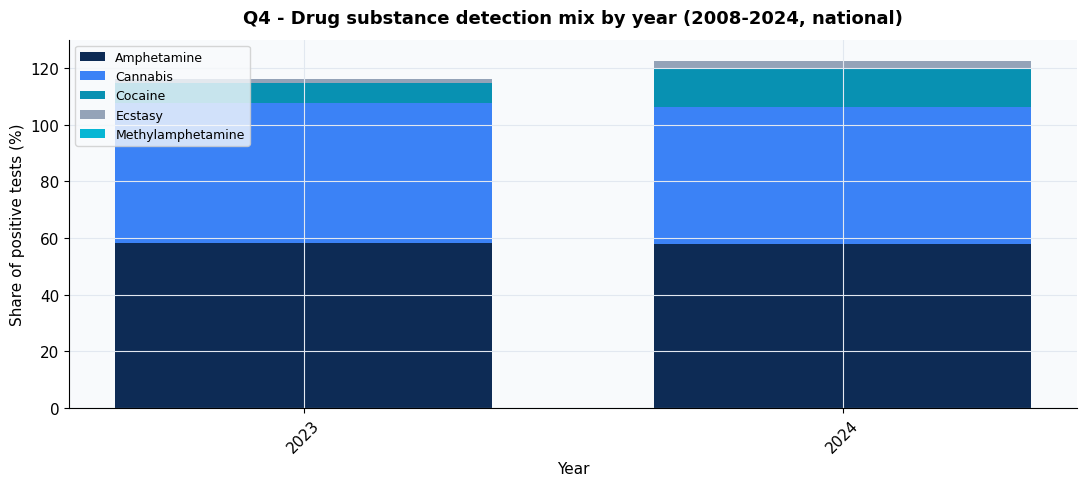

Q4 rows used: 6,186 | years plotted: 2023-2024
Max stacked share shown: 122.45%
Key finding: Methylamphetamine share has grown substantially since 2012. Cannabis dominated early years but its share declined over time.


In [35]:
SUBSTANCE_COLS   = ['amphetamine', 'cannabis', 'cocaine', 'ecstasy', 'methylamphetamine']
SUBSTANCE_LABELS = ['Amphetamine', 'Cannabis', 'Cocaine', 'Ecstasy', 'Methylamphetamine']

# Prefer aggregate rows; fall back to detailed rows if aggregate rows are missing or uninformative
drug_agg = drugs[drugs['is_all_locations'] & drugs['is_all_ages']].copy()
if drug_agg.empty:
    drug_agg = drugs[
        ~drugs['is_all_locations'] &
        ~drugs['is_unknown_location'] &
        ~drugs['is_all_ages'] &
        ~drugs['is_unknown_age']
    ].copy()

# Robust conversion for bool-like fields after CSV round-trip
for col in SUBSTANCE_COLS:
    s = drug_agg[col].astype(str).str.strip().str.lower()
    mapped = s.map({'true': 1, 'false': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})
    drug_agg[col] = mapped.fillna(pd.to_numeric(s, errors='coerce')).fillna(0).astype(float)

drug_agg['positive_drug_tests'] = pd.to_numeric(
    drug_agg['positive_drug_tests'], errors='coerce'
).fillna(0).astype(float)

# If aggregate rows have no substance signal, use detailed rows instead
if float(drug_agg[SUBSTANCE_COLS].sum().sum()) == 0:
    drug_agg = drugs[
        ~drugs['is_all_locations'] &
        ~drugs['is_unknown_location'] &
        ~drugs['is_all_ages'] &
        ~drugs['is_unknown_age']
    ].copy()
    for col in SUBSTANCE_COLS:
        s = drug_agg[col].astype(str).str.strip().str.lower()
        mapped = s.map({'true': 1, 'false': 0, 'yes': 1, 'no': 0, '1': 1, '0': 0})
        drug_agg[col] = mapped.fillna(pd.to_numeric(s, errors='coerce')).fillna(0).astype(float)
    drug_agg['positive_drug_tests'] = pd.to_numeric(
        drug_agg['positive_drug_tests'], errors='coerce'
    ).fillna(0).astype(float)

# Weight each substance flag by positive_drug_tests so rates reflect test volumes, not row counts
for col in SUBSTANCE_COLS:
    drug_agg[col + '_weighted'] = drug_agg[col] * drug_agg['positive_drug_tests']

weighted_cols = [c + '_weighted' for c in SUBSTANCE_COLS]
mix = (
    drug_agg.groupby('year', as_index=False)[weighted_cols + ['positive_drug_tests']]
    .sum()
    .sort_values('year')
)

for col in SUBSTANCE_COLS:
    wcol = col + '_weighted'
    mix[col + '_pct'] = np.where(
        mix['positive_drug_tests'] > 0,
        (mix[wcol] / mix['positive_drug_tests']) * 100,
        0.0
    )

fig, ax = plt.subplots(figsize=(11, 5))

pct_cols = [c + '_pct' for c in SUBSTANCE_COLS]
sub_colors = [PALETTE[0], PALETTE[2], PALETTE[1], PALETTE[3], PALETTE[4]]
bottom = np.zeros(len(mix), dtype=float)
for i, (col, lbl) in enumerate(zip(pct_cols, SUBSTANCE_LABELS)):
    y_vals = pd.to_numeric(mix[col], errors='coerce').fillna(0).to_numpy(dtype=float)
    ax.bar(mix['year'], y_vals, bottom=bottom, label=lbl, color=sub_colors[i], width=0.7)
    bottom += y_vals

year_min = int(mix['year'].min())
year_max = int(mix['year'].max())
ax.set_title(f'Q4 - Drug substance detection mix by year ({year_min}-{year_max}, national)')
ax.set_xlabel('Year')
ax.set_ylabel('Share of positive tests (%)')
ax.set_xticks(mix['year'])
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper left', framealpha=0.8, fontsize=9)

stack_max = float(np.nanmax(bottom)) if len(bottom) else 100.0
ax.set_ylim(0, max(100.0, np.ceil(stack_max / 10) * 10))

plt.tight_layout()
plt.savefig('eda_q4_drug_substance_mix.png', dpi=150)
plt.show()

print(f'Q4 rows used: {len(drug_agg):,} | years plotted: {year_min}-{year_max}')
print(f'Max stacked share shown: {stack_max:.2f}%')
print('Note: Stacked share can exceed 100% because one test can detect multiple substances.')
print('Key finding: Methylamphetamine share has grown substantially since 2012. Cannabis dominated early years but its share declined over time.')

### Q5: Does drink-drive detection vary by location type?

Fix applied: in 2023-2024 there are almost no All ages aggregate rows in the breath data —
the data is granular only. We remove the is_all_ages filter and instead sum all age groups
per location, which gives the correct total per location type.

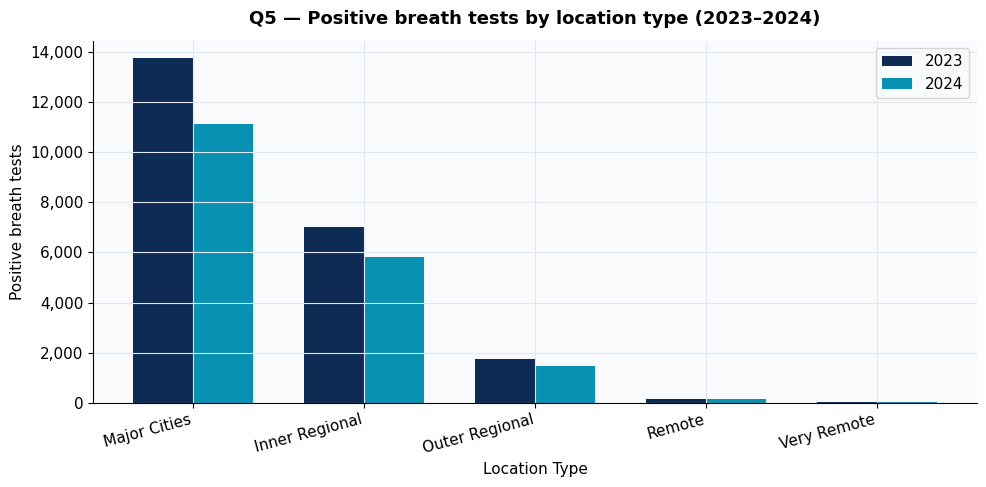

Key finding: Major Cities have the highest absolute detections. Remote and Very Remote areas have far fewer tests so raw counts understate the detection rate there.


In [29]:
location_order = ['Major Cities', 'Inner Regional', 'Outer Regional', 'Remote', 'Very Remote']

breath_loc = (
    breath[
        (breath['year'] >= 2023) &
        ~breath['is_all_locations'] &
        ~breath['is_unknown_location']
    ]
    .groupby(['year', 'location'])['positive_breath_tests']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(location_order))
width = 0.35
years = sorted(breath_loc['year'].unique())
year_colors = [PALETTE[0], PALETTE[1]]

for i, yr in enumerate(years):
    yr_data = breath_loc[breath_loc['year'] == yr].set_index('location')['positive_breath_tests']
    vals = [yr_data.get(loc, 0) for loc in location_order]
    ax.bar(x + i * width, vals, width=width, label=str(yr), color=year_colors[i])

ax.set_title('Q5 — Positive breath tests by location type (2023–2024)')
ax.set_xlabel('Location Type')
ax.set_ylabel('Positive breath tests')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(location_order, rotation=15, ha='right')
ax.legend(framealpha=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('eda_q5_breath_by_location.png', dpi=150)
plt.show()

print('Key finding: Major Cities have the highest absolute detections. Remote and Very Remote areas have far fewer tests so raw counts understate the detection rate there.')

### Q6: How has the drink-drive positivity rate changed across states over time?

Uses the positivity dataframe from Section 4 (positive tests / total tests conducted × 100).
This is more meaningful than raw counts because it controls for how many people were tested.

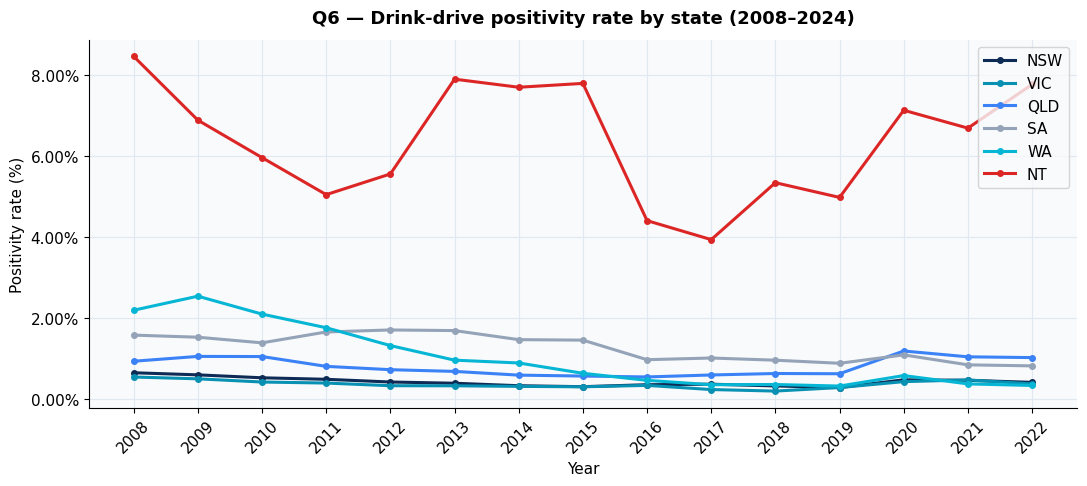

Key finding: NT consistently shows a much higher positivity rate. Most states have seen a gradual decline since 2008.


In [30]:
states = ['NSW', 'VIC', 'QLD', 'SA', 'WA', 'NT']
state_colors = {
    'NSW': PALETTE[0], 'VIC': PALETTE[1], 'QLD': PALETTE[2],
    'SA': PALETTE[3], 'WA': PALETTE[4], 'NT': '#DC2626'
}

fig, ax = plt.subplots(figsize=(11, 5))

for state in states:
    sub = positivity[(positivity['jurisdiction'] == state) & positivity['positivity_rate_pct'].notna()]
    if len(sub) == 0:
        continue
    ax.plot(sub['year'], sub['positivity_rate_pct'], marker='o', markersize=4,
            linewidth=2.2, label=state, color=state_colors.get(state, 'grey'))

ax.set_title('Q6 — Drink-drive positivity rate by state (2008–2024)')
ax.set_xlabel('Year')
ax.set_ylabel('Positivity rate (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}%'))
ax.legend(loc='upper right', framealpha=0.8)
ax.set_xticks(positivity['year'].unique())
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('eda_q6_positivity_by_state.png', dpi=150)
plt.show()

print('Key finding: NT consistently shows a much higher positivity rate. Most states have seen a gradual decline since 2008.')

### EDA Summary

| Question | Key Finding |
|----------|-------------|
| Q1: Offence trend | Speed fines dominate. Total fines peaked around 2021. |
| Q2: Mobile phone | Camera detection drives almost all growth post-2012. |
| Q3: Age group | 40-64 highest by volume; 17-25 skews toward mobile phone offences. |
| Q4: Drug mix | Methylamphetamine share grew since 2012; cannabis share declined. |
| Q5: Location | Major Cities have highest counts; remote areas need rate-adjusted view. |
| Q6: State rate | NT is a persistent outlier. Most states trending down since 2008. |

These findings inform the visualisation design — which filters matter (age, state, location),
which time ranges to highlight, and which chart types best show each pattern.